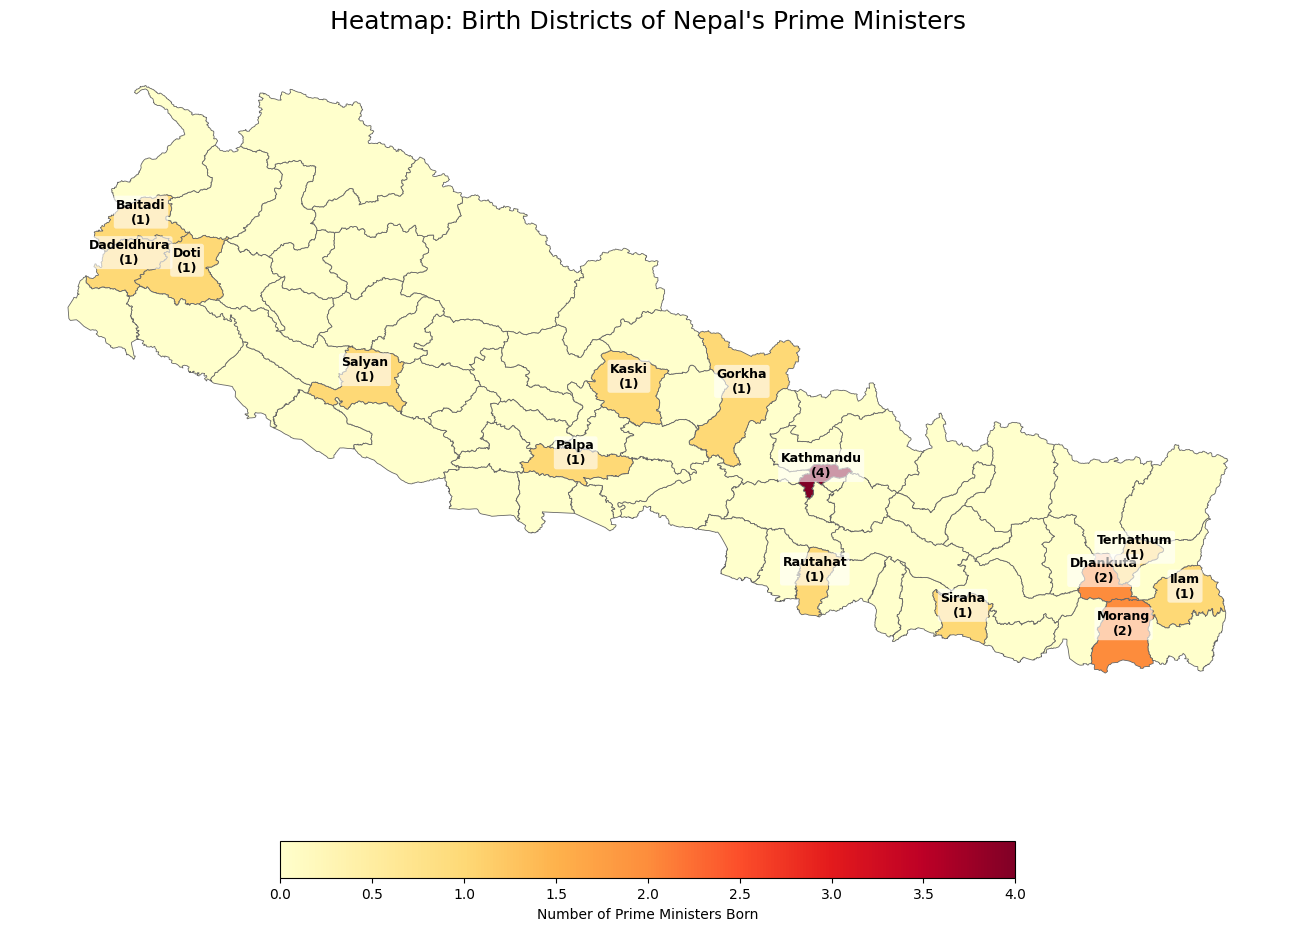

In [6]:
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def create_pm_heatmap(json_file, csv_file):
    # 1. Load the PM birth data
    df_pob = pd.read_csv(csv_file)
    
    # 2. Load the boundary data
    # We use the json module first to avoid potential fiona/gdal driver issues
    with open(json_file, 'r') as f:
        data = json.load(f)
    gdf_local = gpd.GeoDataFrame.from_features(data['features'])

    # 3. Clean and Standardize District Names
    # Convert everything to uppercase to ensure they match
    df_pob['Birthplace'] = df_pob['Birthplace'].str.strip().str.upper()
    gdf_local['DISTRICT'] = gdf_local['DISTRICT'].str.strip().str.upper()

    # Fix specific spelling mismatch (Tehrathum vs Terhathum)
    mapping = {'TEHRATHUM': 'TERHATHUM'}
    df_pob['Birthplace'] = df_pob['Birthplace'].replace(mapping)

    # 4. Aggregate local levels to District level
    # Your JSON contains local units (Palikas), so we dissolve them into 77 districts
    gdf_districts = gdf_local.dissolve(by='DISTRICT').reset_index()

    # 5. Calculate birth counts per district
    pm_counts = df_pob.groupby('Birthplace').size().reset_index(name='PM_Count')
    pm_counts.columns = ['DISTRICT', 'PM_Count']

    # 6. Merge map with counts
    merged = gdf_districts.merge(pm_counts, on='DISTRICT', how='left')
    merged['PM_Count'] = merged['PM_Count'].fillna(0)

    # 7. Plotting
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    
    # Draw the map
    merged.plot(
        column='PM_Count', 
        cmap='YlOrRd', 
        linewidth=0.6, 
        ax=ax, 
        edgecolor='0.4', 
        legend=True,
        legend_kwds={'label': "Number of Prime Ministers Born", 'orientation': "horizontal", 'shrink': 0.5}
    )

    # Add Labels for districts that have at least one PM
    merged['centroid'] = merged.geometry.centroid
    for idx, row in merged.iterrows():
        if row['PM_Count'] > 0:
            name = row['DISTRICT'].title()
            plt.annotate(
                text=f"{name}\n({int(row['PM_Count'])})", 
                xy=(row['centroid'].x, row['centroid'].y),
                horizontalalignment='center', 
                fontsize=9, 
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
            )

    plt.title('Heatmap: Birth Districts of Nepal\'s Prime Ministers', fontsize=18, pad=20)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('pm_heatmap.png', dpi=300)
    plt.show()

# Run the function
create_pm_heatmap('localboundries.json', 'POB.csv')